In [34]:
import os
import subprocess
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')
print("Google Drive is now connected!")

# Step 2: Tell the user where we expect the ZIP to be
print("\nWe will look for your ZIP inside:")
print("  /content/drive/MyDrive/MultiClass_Dataset/")

# Step 3: Check if that folder even exists on Drive
xray_folder = '/content/drive/MyDrive/MultiClass_Dataset'

if os.path.exists(xray_folder):
    print(" 'MultiClass_Dataset' folder found on Drive!")
else:
    print(" 'MultiClass_Dataset' folder NOT found on Drive!")
    print("   Check your Google Drive folder name carefully.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive is now connected!

We will look for your ZIP inside:
  /content/drive/MyDrive/MultiClass_Dataset/
 'MultiClass_Dataset' folder found on Drive!


In [35]:
import os

xray_folder = '/content/drive/MyDrive/MultiClass_Dataset/MultiClass_Dataset'
drive_zip = None

print('Searching for a .zip file inside MultiClass_Dataset...')
for current_folder, sub_folders, file_names in os.walk(xray_folder):
    for filename in file_names:
        if filename.endswith('.zip'):
            drive_zip = os.path.join(current_folder, filename)
            size_gb = os.path.getsize(drive_zip) / (1024 ** 3)
            print(f'Found ZIP: {filename}  ({size_gb:.2f} GB)')
            print(f'Path: {drive_zip}')
            break
    if drive_zip is not None:
        break

if drive_zip is None:
    for current_folder, sub_folders, file_names in os.walk(xray_folder):
        for filename in file_names:
            full_path = os.path.join(current_folder, filename)
            size_mb = os.path.getsize(full_path) / (1024 ** 2)
            print(f'  {full_path}  ({size_mb:.1f} MB)')
    raise FileNotFoundError('Cannot continue without the ZIP file.')

print('ZIP located. Ready for extraction.')

Searching for a .zip file inside MultiClass_Dataset...
Found ZIP: MultiClass.zip  (11.35 GB)
Path: /content/drive/MyDrive/MultiClass_Dataset/MultiClass_Dataset/MultiClass.zip
ZIP located. Ready for extraction.


In [36]:
import os
import subprocess

extract_path = '/content/dataset/'

# These two paths must exist after a successful extraction
raw_check = '/content/dataset/MultiClass/MultiClass_Dataset'
csv_check = '/content/dataset/MultiClass/cleaned_multiclass.csv'

print("STEP 1: Checking if dataset is already extracted on Colab disk...")

# Check if both the images folder AND the CSV file already exist
raw_ready = os.path.exists(raw_check)
csv_ready = os.path.exists(csv_check)

if raw_ready and csv_ready:
    # Great — nothing to do! Skip the extraction.
    print(f"Images folder : {raw_check}")
    print(f"CSV file      : {csv_check}")

else:
    # Not found — we need to extract the ZIP now
    print("STEP 2: Starting extraction from Google Drive...")


    # Create the destination folder if it does not exist yet
    os.makedirs(extract_path, exist_ok=True)

    # Run the unzip command
    result = subprocess.run(
        ['unzip', '-o', '-q', drive_zip, '-d', extract_path],
        capture_output=True,
        text=True
    )

    # Check if unzip worked correctly
    # return code 0 means success, anything else is an error
    if result.returncode != 0:
        print("Extraction FAILED!")
        print(f"   Error message: {result.stderr}")
        raise RuntimeError("Unzip failed! See the error message above.")
    else:
        print("Extraction finished!")

# STEP 3: Verify the extracted folder structure
print(f"Looking inside: {extract_path}\n")

if os.path.exists(extract_path):

    # Walk through up to 4 levels deep only
    for current_folder, sub_folders, file_names in os.walk(extract_path):

        # Calculate how deep we are (0 = top level, 1 = one level down, etc.)
        depth = current_folder.replace(extract_path, '').count(os.sep)

        # Stop printing if we are deeper than 4 levels
        if depth > 4:
            continue

        # Build an indent string so the output looks like a tree
        indent       = '    ' * depth
        folder_name  = os.path.basename(current_folder)
        num_files    = len(file_names)

        print(f"{indent}{folder_name}/   ({num_files} files)")

else:
    print("/content/dataset/ is still empty after extraction!")
    print("   Something went wrong. Please re-run Cell 3.")

STEP 1: Checking if dataset is already extracted on Colab disk...
Images folder : /content/dataset/MultiClass/MultiClass_Dataset
CSV file      : /content/dataset/MultiClass/cleaned_multiclass.csv
Looking inside: /content/dataset/

/   (0 files)
MultiClass/   (1 files)
    MultiClass_Dataset/   (0 files)
        Nodule/   (2300 files)
        Edema/   (2300 files)
        Pneumothorax/   (2300 files)
        Pneumonia/   (2300 files)
        Atelectasis/   (2300 files)
        Consolidation/   (2300 files)
        Emphysema/   (2300 files)
        No Finding/   (2300 files)
        Mass/   (2300 files)
        Infiltration/   (2300 files)
        Cardiomegaly/   (2300 files)
        Effusion/   (2299 files)
        Pleural_Thickening/   (2300 files)


In [38]:
import torch
# ── Paths (from your Untitled9 training notebook) ──────────────────
BASE_PATH = "/content/drive/MyDrive"

# Model saved during training
MODEL_PATH     = BASE_PATH + "/model_output/DenseNet121_V6.pt"

# CSV file (the filtered 6-disease dataset)
TEST_CSV_PATH  = "/content/dataset/MultiClass/cleaned_multiclass.csv"

# Raw images root
RAW_IMAGES_BASE = "/content/dataset/MultiClass/MultiClass_Dataset/"

# ── 6 diseases you trained on (ORDER MUST MATCH label_map) ─────────
SELECTED_DISEASES = [
    'Pneumonia',
    'Cardiomegaly',
    'Pneumothorax',
    'Mass',
    'Emphysema',
    'Atelectasis',
]

label_map   = {disease: idx for idx, disease in enumerate(SELECTED_DISEASES)}
target_names = list(SELECTED_DISEASES)
NUM_CLASSES  = len(target_names);

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Classes ({NUM_CLASSES}): {target_names}")
print(f"Label map: {label_map}")

Using device: cuda
Classes (6): ['Pneumonia', 'Cardiomegaly', 'Pneumothorax', 'Mass', 'Emphysema', 'Atelectasis']
Label map: {'Pneumonia': 0, 'Cardiomegaly': 1, 'Pneumothorax': 2, 'Mass': 3, 'Emphysema': 4, 'Atelectasis': 5}


In [39]:
import subprocess
print('Installing grad-cam...')
subprocess.run(['pip', 'install', 'grad-cam', '-q'])
print('grad-cam installed.')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, f1_score,
                              precision_score, recall_score)
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported.')

Installing grad-cam...
grad-cam installed.
All libraries imported.


In [40]:
CSV_PATH    = '/content/dataset/MultiClass/cleaned_multiclass.csv'
IMAGES_ROOT = '/content/dataset/MultiClass/MultiClass_Dataset/'
SAVE_PATH   = '/content/drive/MyDrive/model_output/ResNet18_MultiClass_6_V2.pt'

print('Loading CSV...')
df_all = pd.read_csv(CSV_PATH)
print(f'Total rows: {len(df_all)}')
print(f'Columns: {list(df_all.columns)}')

print('\nDisease distribution before filtering:')
print(df_all['Finding Labels'].value_counts())

SELECTED_DISEASES = [
    'Pneumonia',
    'Cardiomegaly',
    'Pneumothorax',
    'Mass',
    'Emphysema',
    'Atelectasis',
]
NUM_CLASSES = 6

df = df_all[df_all['Finding Labels'].isin(SELECTED_DISEASES)].copy()
df = df.reset_index(drop=True)

label_map = {disease: idx for idx, disease in enumerate(SELECTED_DISEASES)}
df['label'] = df['Finding Labels'].map(label_map)

print(f'\nAfter filtering to 6 diseases: {len(df)} images')
print(df['Finding Labels'].value_counts())
print(f'Label map: {label_map}')

Loading CSV...
Total rows: 29899
Columns: ['Image Index', 'Finding Labels', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position']

Disease distribution before filtering:
Finding Labels
Cardiomegaly          2300
Emphysema             2300
No Finding            2300
Infiltration          2300
Mass                  2300
Pleural_Thickening    2300
Nodule                2300
Atelectasis           2300
Pneumothorax          2300
Edema                 2300
Pneumonia             2300
Consolidation         2300
Effusion              2299
Name: count, dtype: int64

After filtering to 6 diseases: 13800 images
Finding Labels
Cardiomegaly    2300
Emphysema       2300
Mass            2300
Atelectasis     2300
Pneumothorax    2300
Pneumonia       2300
Name: count, dtype: int64
Label map: {'Pneumonia': 0, 'Cardiomegaly': 1, 'Pneumothorax': 2, 'Mass': 3, 'Emphysema': 4, 'Atelectasis': 5}


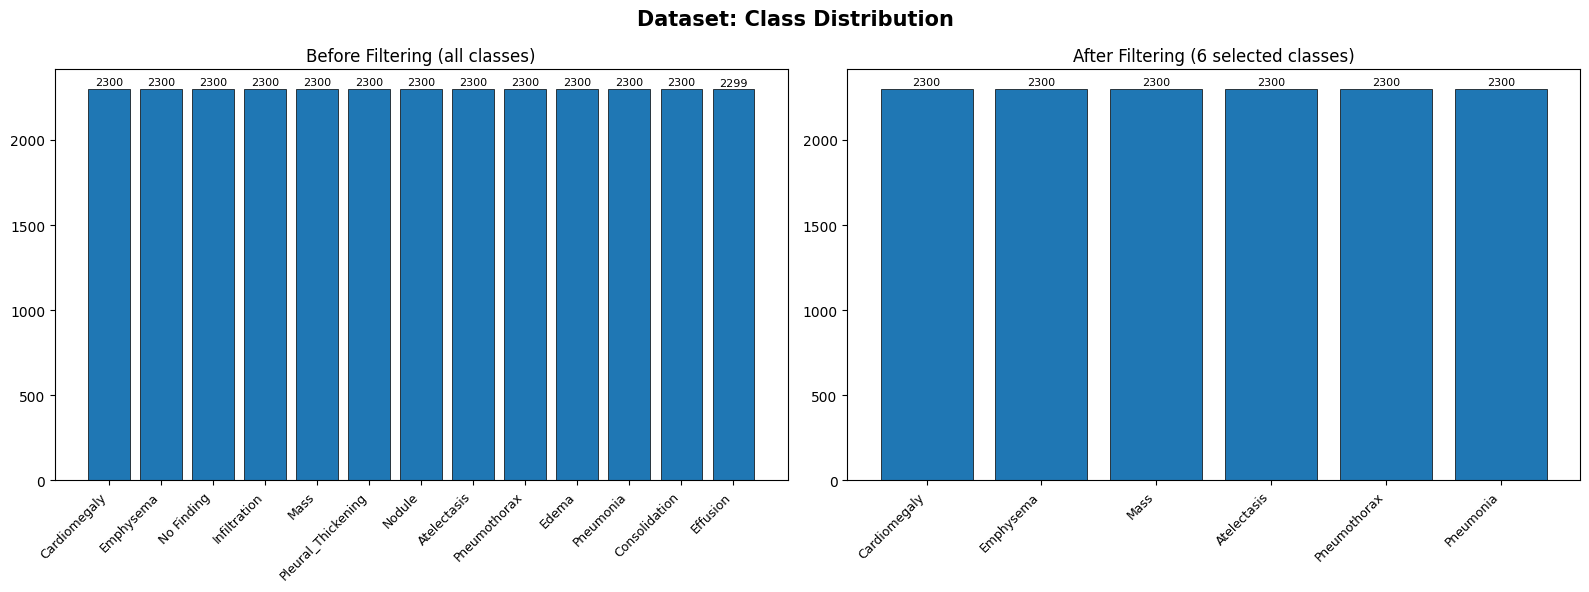

Plot saved: class distribution.


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Dataset: Class Distribution', fontsize=15, fontweight='bold')

before_counts = df_all['Finding Labels'].value_counts()
axes[0].bar(range(len(before_counts)), before_counts.values, edgecolor='black', linewidth=0.5)
axes[0].set_title('Before Filtering (all classes)')
axes[0].set_xticks(range(len(before_counts)))
axes[0].set_xticklabels(before_counts.index, rotation=45, ha='right', fontsize=9)
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=8)

after_counts = df['Finding Labels'].value_counts()
axes[1].bar(range(len(after_counts)), after_counts.values, edgecolor='black', linewidth=0.5)
axes[1].set_title('After Filtering (6 selected classes)')
axes[1].set_xticks(range(len(after_counts)))
axes[1].set_xticklabels(after_counts.index, rotation=45, ha='right', fontsize=9)
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_output/resnet18_plot1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: class distribution.')

In [42]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df)} images')
print(f'Val   : {len(val_df)} images')
print(f'Test  : {len(test_df)} images')

Train : 9660 images
Val   : 2070 images
Test  : 2070 images


In [43]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

print('Building image path lookup dictionary...')
image_path_dict = {}
for class_folder in os.listdir(IMAGES_ROOT):
    class_path = os.path.join(IMAGES_ROOT, class_folder)
    if os.path.isdir(class_path):
        for fname in os.listdir(class_path):
            if fname.endswith('.png'):
                image_path_dict[fname] = os.path.join(class_path, fname)
print(f'Found {len(image_path_dict)} images in dictionary')

class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_dict, transform=None):
        self.df         = dataframe
        self.image_dict = image_dict
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        filename = row['Image Index']
        label    = int(row['label'])
        img_path = self.image_dict.get(filename, None)

        if img_path is None or not os.path.exists(img_path):
            image = Image.new('RGB', (224, 224), color=(0, 0, 0))
        else:
            image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# Same augmentation as ResNet-50 notebook
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3))
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ChestXrayDataset(train_df, image_path_dict, transform=train_transform)
val_dataset   = ChestXrayDataset(val_df,   image_path_dict, transform=val_test_transform)
test_dataset  = ChestXrayDataset(test_df,  image_path_dict, transform=val_test_transform)

# ResNet-18 is lighter — can use batch_size=128 or even 256 if VRAM allows
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

print(f'Train : {len(train_loader)} batches x 128 = {len(train_dataset)} images')
print(f'Val   : {len(val_loader)} batches x 128 = {len(val_dataset)} images')
print(f'Test  : {len(test_loader)} batches x 128 = {len(test_dataset)} images')

Building image path lookup dictionary...
Found 25564 images in dictionary
Train : 76 batches x 128 = 9660 images
Val   : 17 batches x 128 = 2070 images
Test  : 17 batches x 128 = 2070 images


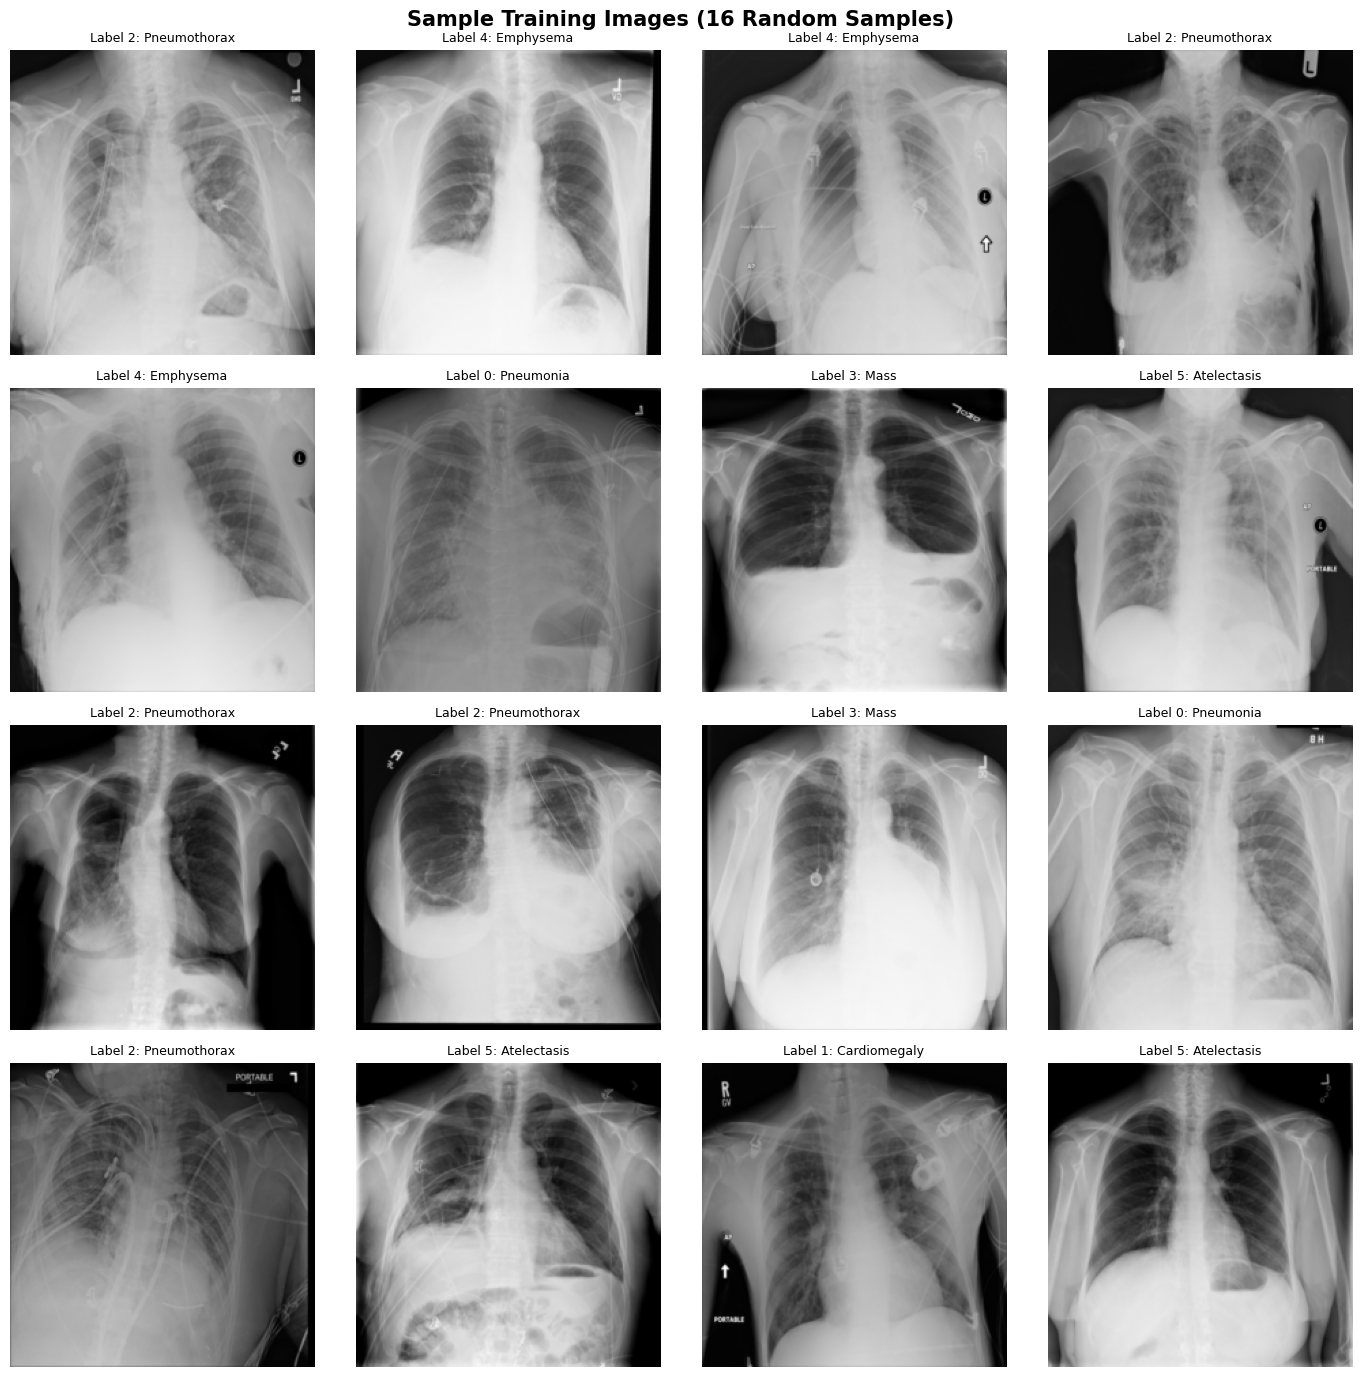

Plot saved: sample image grid.


In [44]:
viz_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
viz_dataset = ChestXrayDataset(train_df, image_path_dict, transform=viz_transform)
viz_loader  = DataLoader(viz_dataset, batch_size=16, shuffle=True)

images_batch, labels_batch = next(iter(viz_loader))
reverse_label_map = {v: k for k, v in label_map.items()}

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Sample Training Images (16 Random Samples)', fontsize=15, fontweight='bold')

for i in range(16):
    ax     = axes[i // 4][i % 4]
    img_np = images_batch[i].permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 1)
    ax.imshow(img_np, cmap='gray')
    disease_name = reverse_label_map[labels_batch[i].item()]
    ax.set_title(f'Label {labels_batch[i].item()}: {disease_name}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_output/resnet18_plot2_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: sample image grid.')

In [45]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import time

EPOCHS = 50

print('Building ResNet-18...')

# ── KEY CHANGE 1: Use ResNet-18 pretrained weights ──
model = models.resnet18(pretrained=True)

# Unfreeze ALL layers — X-rays are very different from ImageNet photos
for param in model.parameters():
    param.requires_grad = True

# ── KEY CHANGE 2: ResNet-18 outputs 512 features (not 2048 like ResNet-50) ──
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.BatchNorm1d(in_features),
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(p=0.3),
    nn.Linear(256, NUM_CLASSES)      # final output: 6 class scores
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)

if torch.cuda.is_available():
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {torch.cuda.get_device_name(0)}  |  VRAM: {total_vram:.1f} GB')

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')       # ~11M (vs ~25M for ResNet-50)
print(f'Trainable params: {trainable_params:,}')

# MixUp: blend two images and their labels together during training
def mixup_data(images, labels, alpha=0.3):
    lam        = np.random.beta(alpha, alpha)
    batch_size = images.size(0)
    rand_index = torch.randperm(batch_size).to(images.device)
    mixed_images = lam * images + (1 - lam) * images[rand_index]
    labels_a     = labels
    labels_b     = labels[rand_index]
    return mixed_images, labels_a, labels_b, lam

def mixup_criterion(criterion, outputs, labels_a, labels_b, lam):
    return lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)

# Print initial weights of the final linear layer
final_linear = model.fc[6]
weights = final_linear.weight.data.cpu().numpy()
biases  = final_linear.bias.data.cpu().numpy()

print('\nInitial weights of the final linear layer (before training):')
print(f'{"#":<4} {"Class":<22} {"Bias":>8} {"W Min":>10} {"W Max":>10} {"W Mean":>10}')
print('-' * 65)
for i in range(NUM_CLASSES):
    print(f'{i:<4} {SELECTED_DISEASES[i]:<22} {biases[i]:>8.4f} '
          f'{weights[i].min():>10.4f} {weights[i].max():>10.4f} {weights[i].mean():>10.4f}')
print('Note: near-zero means is normal - weights are randomly initialized by PyTorch.')

Building ResNet-18...
GPU: NVIDIA L4  |  VRAM: 23.7 GB
Total params    : 11,310,918
Trainable params: 11,310,918

Initial weights of the final linear layer (before training):
#    Class                      Bias      W Min      W Max     W Mean
-----------------------------------------------------------------
0    Pneumonia                0.0303    -0.0605     0.0621    -0.0023
1    Cardiomegaly             0.0512    -0.0619     0.0622     0.0018
2    Pneumothorax             0.0525    -0.0622     0.0606    -0.0047
3    Mass                    -0.0203    -0.0610     0.0623    -0.0034
4    Emphysema               -0.0461    -0.0601     0.0623     0.0062
5    Atelectasis             -0.0349    -0.0619     0.0612     0.0011
Note: near-zero means is normal - weights are randomly initialized by PyTorch.


In [46]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import time

EPOCHS = 65

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── KEY CHANGE 3: ResNet-18 layer structure is layer1/layer2/layer3/layer4 same as ResNet-50
#    but LRs are slightly higher since the model is more stable with fewer params ──
optimizer = optim.AdamW([
    {'params': model.layer1.parameters(), 'lr': 8e-6},   # basic edge/texture detectors
    {'params': model.layer2.parameters(), 'lr': 1.5e-5},
    {'params': model.layer3.parameters(), 'lr': 2.5e-5},
    {'params': model.layer4.parameters(), 'lr': 4e-5},
    {'params': model.fc.parameters(),     'lr': 1.2e-4},  # new untrained head gets highest LR
],
    weight_decay=1e-3
)

scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-7)

patience         = 10
no_improve_count = 0
best_val_acc     = 0.0
best_epoch       = 0

MIXUP_STOP_EPOCH = 35

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

print(f'Training ResNet-18: {EPOCHS} epochs | batch=128')
print(f'Protections: MixUp + LabelSmoothing + Dropout + WeightDecay + EarlyStopping + GradClip')
print('=' * 75)

for epoch in range(EPOCHS):
    epoch_start          = time.time()
    use_mixup_this_epoch = (epoch < MIXUP_STOP_EPOCH)

    # ---- TRAINING PHASE ----
    model.train()
    running_loss  = 0.0
    correct_train = 0
    total_train   = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        if use_mixup_this_epoch:
            mixed_images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=0.3)
            outputs = model(mixed_images)
            loss    = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        else:
            outputs = model(images)
            loss    = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss  += loss.item()
        _, predicted   = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train   += labels.size(0)

        if (batch_idx + 1) % 30 == 0:
            tag = 'MixUp ON' if use_mixup_this_epoch else 'MixUp OFF'
            print(f'  Ep {epoch+1}/{EPOCHS} | Batch {batch_idx+1}/{len(train_loader)} '
                  f'| Loss: {running_loss/(batch_idx+1):.4f} | {tag}')

    avg_train_loss = running_loss / len(train_loader)
    avg_train_acc  = 100.0 * correct_train / total_train

    # ---- VALIDATION PHASE ----
    model.eval()
    val_loss    = 0.0
    correct_val = 0
    total_val   = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images  = images.to(device, non_blocking=True)
            labels  = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss    = nn.CrossEntropyLoss()(outputs, labels)
            val_loss    += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val   += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc  = 100.0 * correct_val / total_val

    scheduler.step(epoch)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(avg_train_acc)
    val_accs.append(avg_val_acc)

    if (epoch + 1) % 10 == 0 and torch.cuda.is_available():
        used_vram = torch.cuda.memory_allocated(0) / 1e9
        peak_vram = torch.cuda.max_memory_allocated(0) / 1e9
        print(f'  GPU Memory -> Used: {used_vram:.1f}GB | Peak: {peak_vram:.1f}GB')

    if avg_val_acc > best_val_acc:
        best_val_acc     = avg_val_acc
        best_epoch       = epoch + 1
        no_improve_count = 0
        torch.save(model.state_dict(), SAVE_PATH)
        saved_marker = ' <- SAVED (new best)'
    else:
        no_improve_count += 1
        saved_marker = f' (no improve: {no_improve_count}/{patience})'

    overfit_gap     = avg_train_acc - avg_val_acc
    overfit_warning = f' WARNING: OVERFIT GAP {overfit_gap:.1f}%' if overfit_gap > 15 else ''

    epoch_time = time.time() - epoch_start
    print(f'Epoch {epoch+1:2d}/{EPOCHS} | '
          f'Train: {avg_train_acc:.2f}% | Val: {avg_val_acc:.2f}%'
          f'{saved_marker}{overfit_warning} | {epoch_time:.1f}s')
    print('-' * 75)

    if no_improve_count >= patience:
        print(f'Early stopping at epoch {epoch+1} - no improvement for {patience} epochs.')
        break

print(f'Done! Best Val Accuracy: {best_val_acc:.2f}% at epoch {best_epoch}')
print(f'Model saved to: {SAVE_PATH}')

Training ResNet-18: 65 epochs | batch=128
Protections: MixUp + LabelSmoothing + Dropout + WeightDecay + EarlyStopping + GradClip
  Ep 1/65 | Batch 30/76 | Loss: 1.9097 | MixUp ON
  Ep 1/65 | Batch 60/76 | Loss: 1.8801 | MixUp ON
Epoch  1/65 | Train: 19.87% | Val: 29.03% <- SAVED (new best) | 74.8s
---------------------------------------------------------------------------
  Ep 2/65 | Batch 30/76 | Loss: 1.7796 | MixUp ON
  Ep 2/65 | Batch 60/76 | Loss: 1.7862 | MixUp ON
Epoch  2/65 | Train: 23.01% | Val: 32.22% <- SAVED (new best) | 73.5s
---------------------------------------------------------------------------
  Ep 3/65 | Batch 30/76 | Loss: 1.7276 | MixUp ON
  Ep 3/65 | Batch 60/76 | Loss: 1.7306 | MixUp ON
Epoch  3/65 | Train: 26.84% | Val: 34.01% <- SAVED (new best) | 74.0s
---------------------------------------------------------------------------
  Ep 4/65 | Batch 30/76 | Loss: 1.7351 | MixUp ON
  Ep 4/65 | Batch 60/76 | Loss: 1.7128 | MixUp ON
Epoch  4/65 | Train: 25.11% | Val

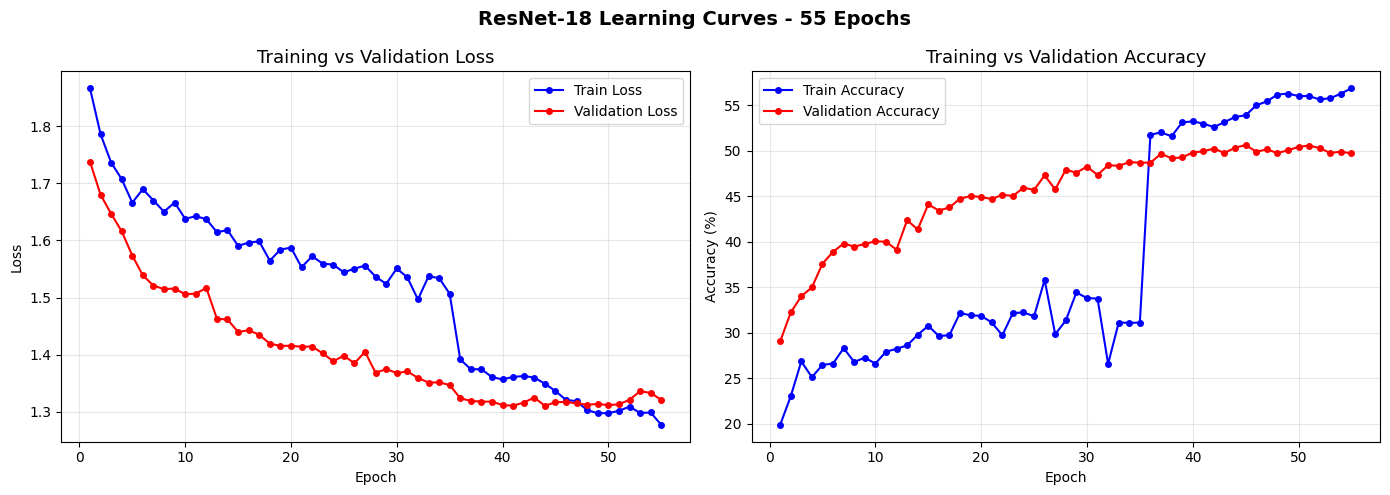

Learning curves saved.


In [62]:
epochs_range = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, train_losses, 'b-o', label='Train Loss',      markersize=4)
ax1.plot(epochs_range, val_losses,   'r-o', label='Validation Loss', markersize=4)
ax1.set_title('Training vs Validation Loss', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, train_accs, 'b-o', label='Train Accuracy',      markersize=4)
ax2.plot(epochs_range, val_accs,   'r-o', label='Validation Accuracy', markersize=4)
ax2.set_title('Training vs Validation Accuracy', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'ResNet-18 Learning Curves - {len(train_losses)} Epochs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_output/resnet18_learning_curves.png', dpi=150)
plt.show()
print('Learning curves saved.')

In [63]:
print('Loading best model weights...')
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()
print('Best model loaded.')

all_preds  = []
all_labels = []
all_probs  = []

print('Running evaluation on test set...')
with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs        = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_acc = 100.0 * (all_preds == all_labels).sum() / len(all_labels)
print(f'Test Set Accuracy: {test_acc:.2f}%')
print('\nPer-Class Classification Report:')
print(classification_report(all_labels, all_preds, target_names=SELECTED_DISEASES))

Loading best model weights...
Best model loaded.
Running evaluation on test set...
Test Set Accuracy: 51.88%

Per-Class Classification Report:
              precision    recall  f1-score   support

   Pneumonia       0.62      0.57      0.60       345
Cardiomegaly       0.62      0.79      0.69       345
Pneumothorax       0.42      0.50      0.46       345
        Mass       0.52      0.47      0.49       345
   Emphysema       0.58      0.34      0.43       345
 Atelectasis       0.39      0.44      0.41       345

    accuracy                           0.52      2070
   macro avg       0.53      0.52      0.51      2070
weighted avg       0.53      0.52      0.51      2070



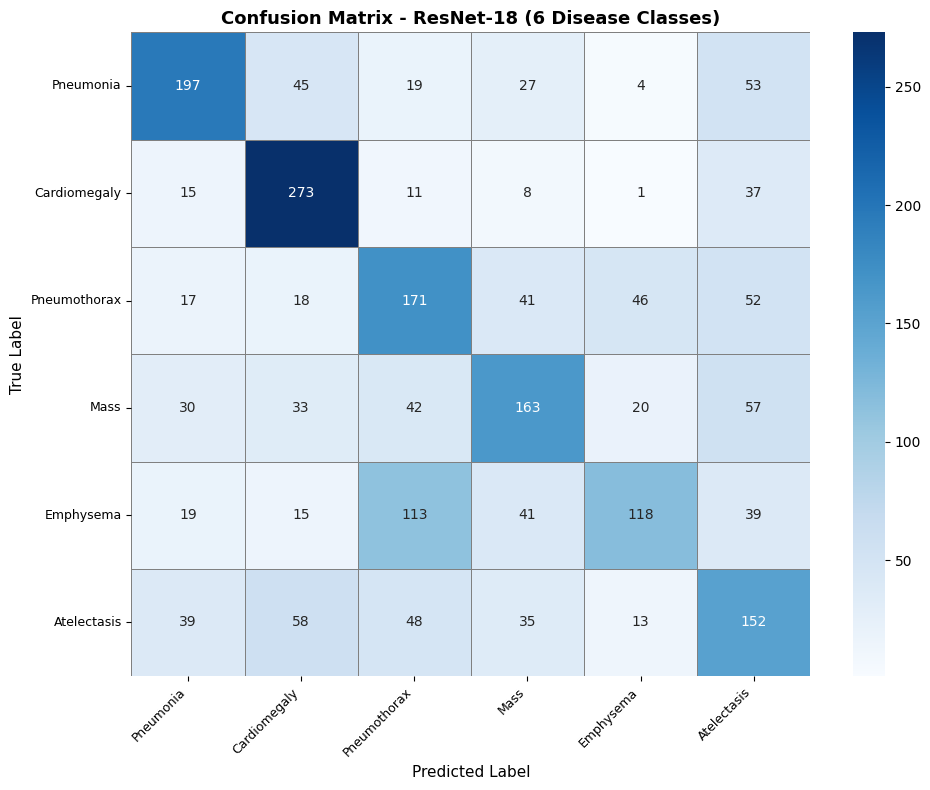

Confusion matrix saved.


In [64]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SELECTED_DISEASES, yticklabels=SELECTED_DISEASES,
            linewidths=0.5, linecolor='gray')
plt.title(f'Confusion Matrix - ResNet-18 ({NUM_CLASSES} Disease Classes)', fontsize=13, fontweight='bold')
plt.ylabel('True Label',      fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_output/resnet18_confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved.')

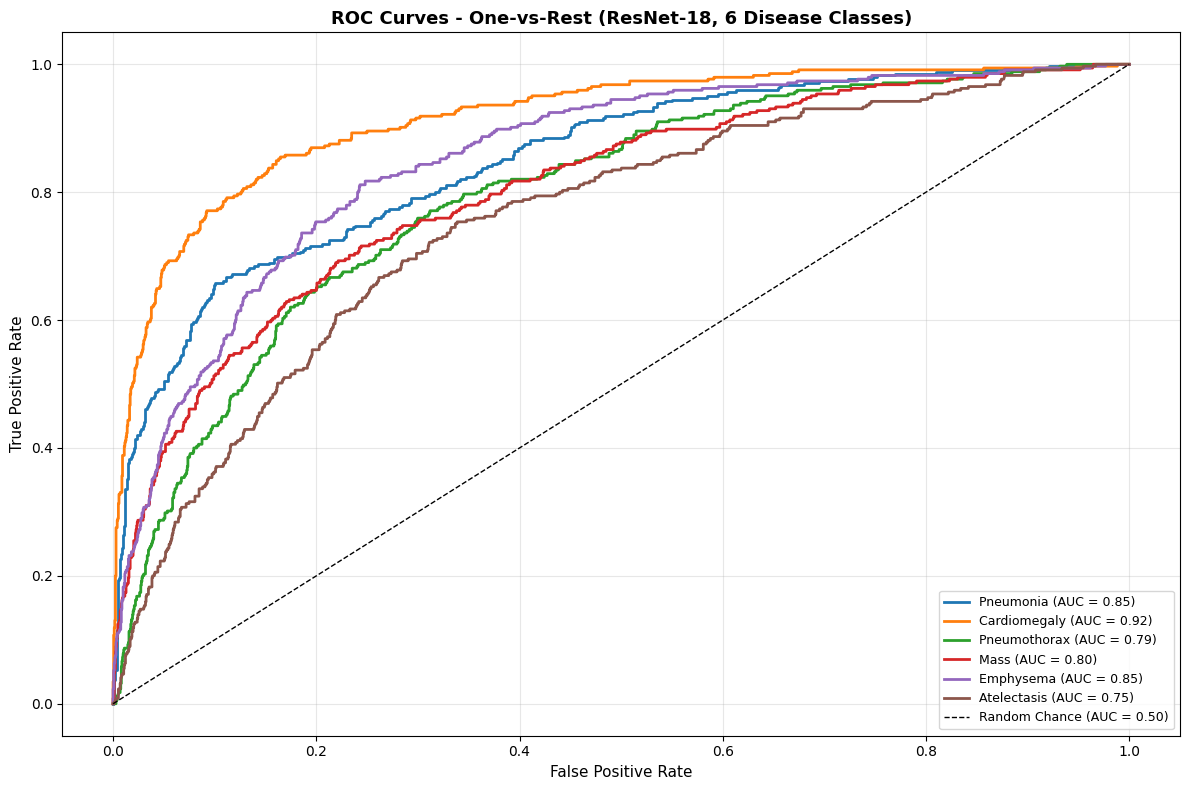

ROC curves saved.


In [65]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(12, 8))
colors_roc = plt.cm.tab10.colors

for i, class_name in enumerate(SELECTED_DISEASES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc      = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors_roc[i], lw=2,
             label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance (AUC = 0.50)')
plt.title(f'ROC Curves - One-vs-Rest (ResNet-18, {NUM_CLASSES} Disease Classes)', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate',  fontsize=11)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_output/resnet18_roc_curves.png', dpi=150)
plt.show()
print('ROC curves saved.')

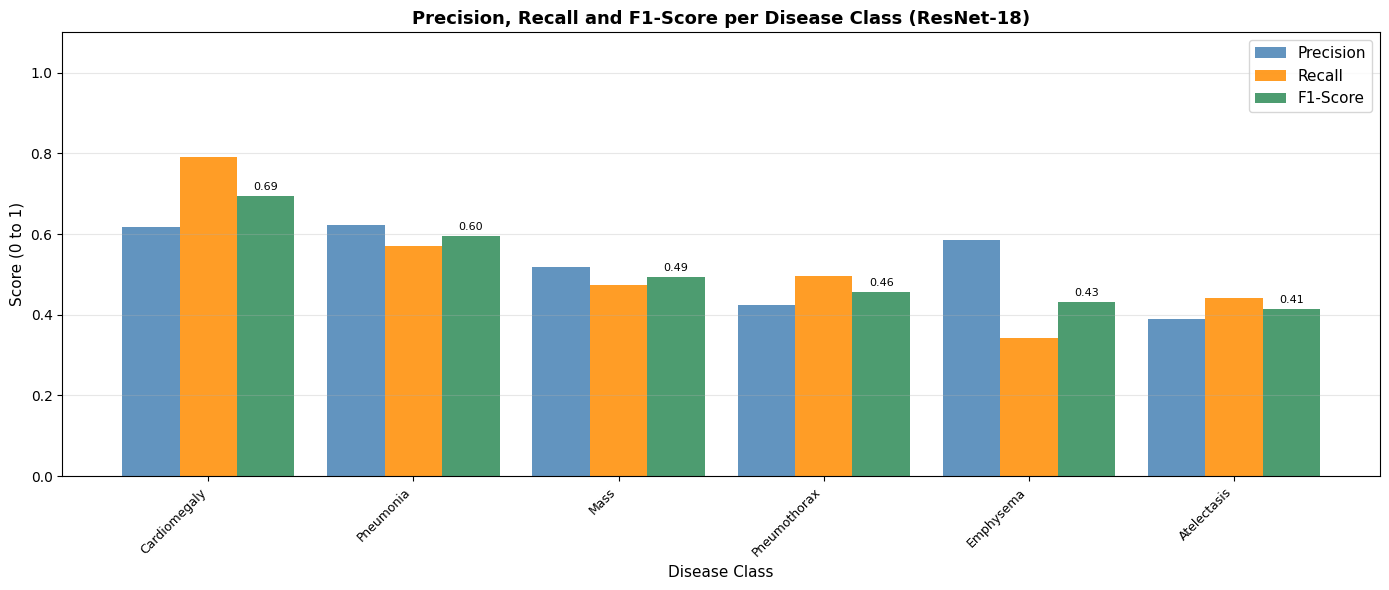

F1-score chart saved.


In [66]:
from sklearn.metrics import f1_score, precision_score, recall_score

f1_scores  = f1_score(all_labels, all_preds, average=None)
precisions = precision_score(all_labels, all_preds, average=None, zero_division=0)
recalls    = recall_score(all_labels, all_preds, average=None, zero_division=0)

sorted_idx  = np.argsort(f1_scores)[::-1]
sorted_cls  = [SELECTED_DISEASES[i] for i in sorted_idx]
sorted_f1   = f1_scores[sorted_idx]
sorted_prec = precisions[sorted_idx]
sorted_rec  = recalls[sorted_idx]

x     = np.arange(NUM_CLASSES)
width = 0.28

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, sorted_prec, width, label='Precision', color='steelblue',  alpha=0.85)
ax.bar(x,         sorted_rec,  width, label='Recall',    color='darkorange', alpha=0.85)
ax.bar(x + width, sorted_f1,   width, label='F1-Score',  color='seagreen',   alpha=0.85)

ax.set_title('Precision, Recall and F1-Score per Disease Class (ResNet-18)', fontsize=13, fontweight='bold')
ax.set_xlabel('Disease Class', fontsize=11)
ax.set_ylabel('Score (0 to 1)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(sorted_cls, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

for bar in ax.patches[2 * NUM_CLASSES:]:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_output/resnet18_f1_scores.png', dpi=150)
plt.show()
print('F1-score chart saved.')

Generating Grad-CAM heatmaps for 8 test images...


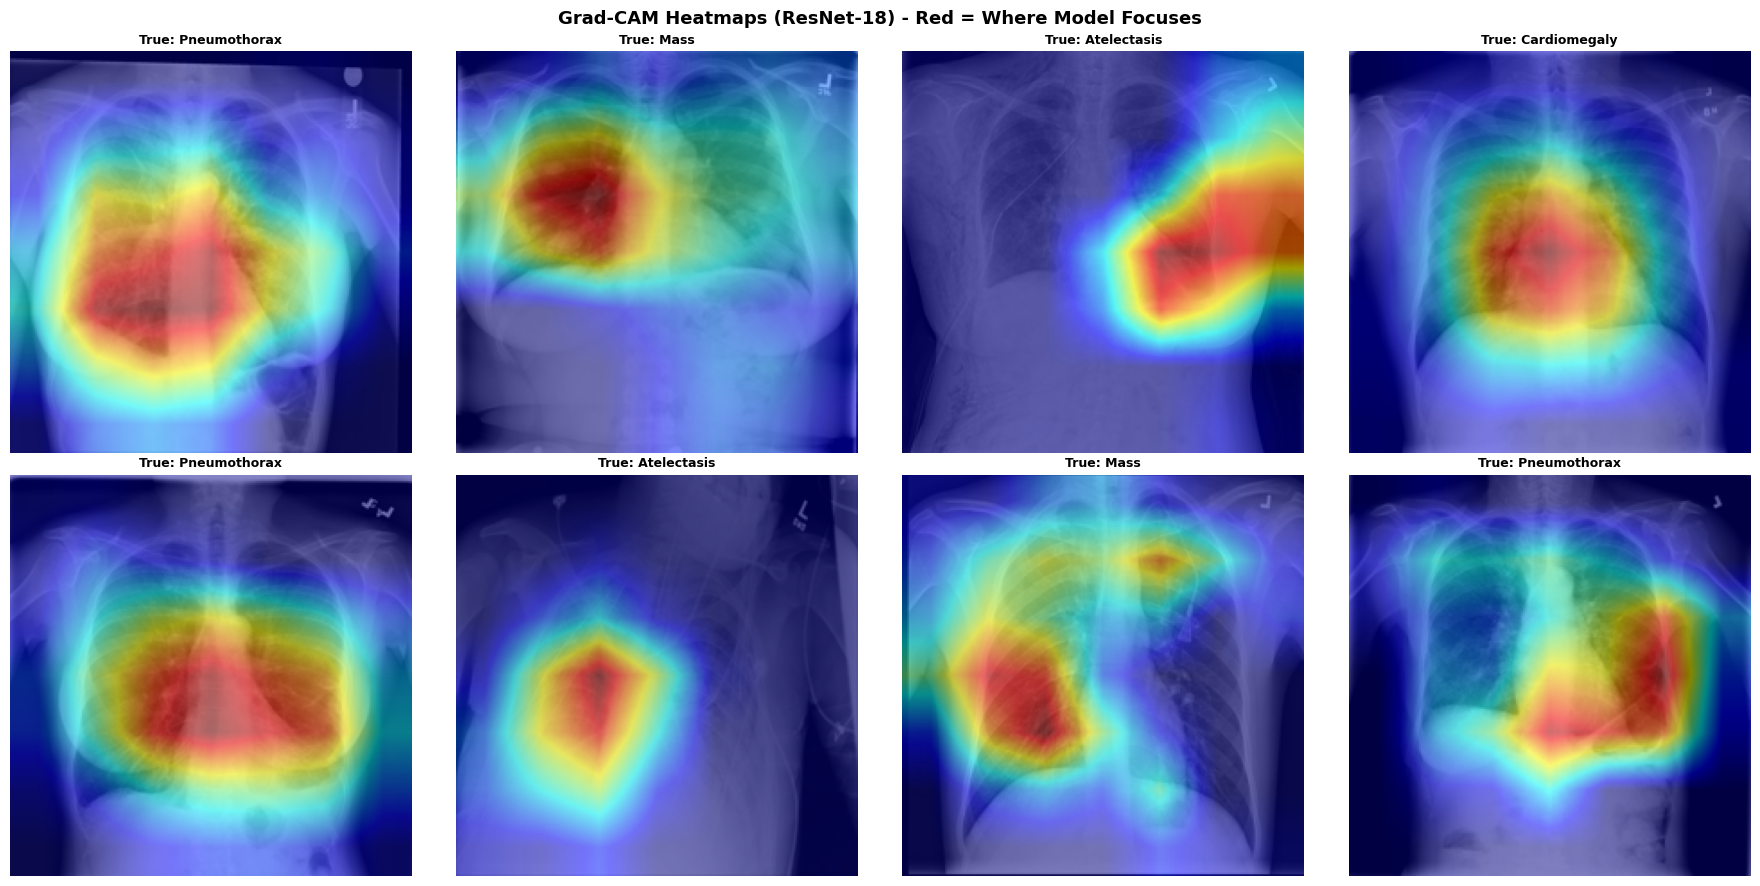

Grad-CAM heatmaps saved.


In [67]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── KEY CHANGE 4: ResNet-18 also uses model.layer4[-1] as the target layer ──
# This is the same attribute name as ResNet-50, so no change needed here.
target_layer = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

print('Generating Grad-CAM heatmaps for 8 test images...')

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

count = 0
for idx in range(len(test_df)):
    if count >= 8:
        break

    row      = test_df.iloc[idx]
    img_name = row['Image Index']
    label    = int(row['label'])
    img_path = image_path_dict.get(img_name)

    if img_path is None or not os.path.exists(img_path):
        continue

    orig_img = Image.open(img_path).convert('RGB').resize((224, 224))
    orig_np  = np.array(orig_img) / 255.0

    input_tensor  = val_test_transform(orig_img).unsqueeze(0).to(device)
    targets       = [ClassifierOutputTarget(label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    visualization = show_cam_on_image(orig_np.astype(np.float32), grayscale_cam, use_rgb=True)

    axes[count].imshow(visualization)
    axes[count].set_title(f'True: {SELECTED_DISEASES[label]}', fontsize=9, fontweight='bold')
    axes[count].axis('off')
    count += 1

plt.suptitle('Grad-CAM Heatmaps (ResNet-18) - Red = Where Model Focuses', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_output/resnet18_gradcam_heatmaps.png', dpi=150)
plt.show()
print('Grad-CAM heatmaps saved.')

In [68]:
plots = [
    '/content/drive/MyDrive/model_output/resnet18_plot1_class_distribution.png',
    '/content/drive/MyDrive/model_output/resnet18_plot2_sample_images.png',
    '/content/drive/MyDrive/model_output/resnet18_learning_curves.png',
    '/content/drive/MyDrive/model_output/resnet18_confusion_matrix.png',
    '/content/drive/MyDrive/model_output/resnet18_roc_curves.png',
    '/content/drive/MyDrive/model_output/resnet18_f1_scores.png',
    '/content/drive/MyDrive/model_output/resnet18_gradcam_heatmaps.png',
]

print('Checking saved plots:')
for plot_path in plots:
    status = 'Found' if os.path.exists(plot_path) else 'NOT FOUND'
    print(f'  {status}: {os.path.basename(plot_path)}')

current_best_val_loss = val_losses[best_epoch - 1]

print('\n========== FINAL TRAINING SUMMARY (ResNet-18) ==========')
print(f'Model       : ResNet-18 (pretrained ImageNet)')
print(f'Dataset     : MultiClass (NIH ChestX-ray14 filtered)')
print(f'Classes     : {NUM_CLASSES}')
print(f'Train size  : {len(train_df)} images')
print(f'Val size    : {len(val_df)} images')
print(f'Test size   : {len(test_df)} images')
print(f'Epochs run  : {len(train_losses)}')
print(f'Batch size  : {train_loader.batch_size}')
print(f'Best Epoch  : {best_epoch}')
print(f'Best Val Loss : {current_best_val_loss:.4f}')
print(f'Test Accuracy : {test_acc:.2f}%')
print(f'Model saved to: {SAVE_PATH}')
print('=======================================================')

Checking saved plots:
  Found: resnet18_plot1_class_distribution.png
  Found: resnet18_plot2_sample_images.png
  Found: resnet18_learning_curves.png
  Found: resnet18_confusion_matrix.png
  Found: resnet18_roc_curves.png
  Found: resnet18_f1_scores.png
  Found: resnet18_gradcam_heatmaps.png

========== FINAL TRAINING SUMMARY (ResNet-18) ==========
Model       : ResNet-18 (pretrained ImageNet)
Dataset     : MultiClass (NIH ChestX-ray14 filtered)
Classes     : 6
Train size  : 9660 images
Val size    : 2070 images
Test size   : 2070 images
Epochs run  : 55
Batch size  : 128
Best Epoch  : 45
Best Val Loss : 1.3171
Test Accuracy : 51.88%
Model saved to: /content/drive/MyDrive/model_output/ResNet18_MultiClass_6_V2.pt
